# 📧 Phishing Email Classification Pipeline

## Overview
This notebook implements an end-to-end machine learning pipeline for detecting phishing emails.
The system analyzes the email body to classify messages as legitimate (safe) or phishing.

## 🎯 Objectives
- **Data Loading**: Load and explore the email dataset
- **Data Cleaning**: Handle missing values, remove duplicates, normalize email text
- **Feature Engineering**: Transform email body content using TF-IDF
- **Model Training**: Train multiple classification algorithms
- **Model Evaluation**: Measure performance using cross-validation and test metrics
- **Model Persistence**: Save the final trained model and vectorizer

## 📊 Dataset
- **Source**: phishing_email.csv
- **Features**: Raw email body text
- **Labels**: Binary (0 = Safe, 1 = Phishing)
- **Preprocessing**: Cleaning, normalization, duplicate removal

## 🤖 Machine Learning Approach

### Email Text Preprocessing
- Convert text to lowercase
- Normalize whitespace
- Remove duplicates
- Remove missing entries

### Feature Extraction
**TF-IDF Vectorization** converts the email body into numerical features for machine learning models.

**N-grams:**
- Unigrams (single words)
- Bigrams (common email phrase patterns)
- Trigrams (multi-word phishing patterns)

### Models Evaluated
1. **Logistic Regression**
2. **Complement Naive Bayes**
3. **Linear SVM (Calibrated)**
4. **Voting Classifier** (ensemble of all models)

### Evaluation Strategy
- **10-fold Stratified Cross-Validation**
- **20% Test Set**
- **Metrics**: Accuracy, Precision, Recall, F1, Classification Report

## 📦 Output Artifacts
- **tfidf_vectorizer.pkl**
- **model.pkl**

In [1]:
import pandas as pd
import time
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from tqdm import tqdm 
from wordcloud import WordCloud, STOPWORDS
from PIL import Image
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, average_precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Load dataset
print("📁 Loading phishing_email.csv...")
try:
    df = pd.read_csv("phishing_email.csv", engine="python", on_bad_lines="skip")
    print(f"✅ Loaded phishing_email.csv → {df.shape}")
except Exception as e:
    print(f"❌ Error loading phishing_email.csv: {e}")
    raise

print(f"\n📊 Initial dataset shape: {df.shape}")
print(f"\n📋 Column names:")
print(df.columns.tolist())
print(f"\n📊 First few rows:")
print(df.head())

# Column mapping
text_col = 'text_combined'
label_col = 'label'

print(f"\n✅ Using '{text_col}' as email body column")
print(f"✅ Using '{label_col}' as label column")

clean_df = df[[text_col, label_col]].copy()
clean_df.columns = ['email_text', 'label']

print(f"\n🏷️ Original label distribution:")
print(clean_df['label'].value_counts())

# Label cleaning
if clean_df['label'].dtype == 'object':
    unique_labels = clean_df['label'].unique()
    print(f"\nUnique labels: {unique_labels}")

    phishing_keywords = ['phishing', 'spam', 'malicious', '1', 'true', 'yes']
    safe_keywords = ['safe', 'ham', 'legitimate', 'legit', '0', 'false', 'no']
    
    def map_label(label):
        label_lower = str(label).lower().strip()
        if any(k in label_lower for k in phishing_keywords):
            return 1
        if any(k in label_lower for k in safe_keywords):
            return 0
        return np.nan

    clean_df['label'] = clean_df['label'].apply(map_label)
else:
    clean_df['label'] = pd.to_numeric(clean_df['label'], errors='coerce')

clean_df = clean_df.dropna(subset=['label'])
clean_df['label'] = clean_df['label'].astype(int)

print(f"\n📊 Cleaned label distribution:")
print(clean_df['label'].value_counts())

# Remove invalid or missing emails
print("\n🔍 Checking for null values:")
print(clean_df.isnull().sum())

initial_count_before_null = len(clean_df)
clean_df = clean_df.dropna(subset=['email_text'])
print(f"\n🗑️ Removed {initial_count_before_null - len(clean_df)} rows with missing email text")

clean_df['email_text'] = clean_df['email_text'].fillna("")

# Deduplicate
print(f"\n🔍 Checking for duplicates:")
duplicate_count = clean_df.duplicated(subset=['email_text']).sum()
print(f"Total duplicate emails: {duplicate_count}")

def clean_text(text):
    text = re.sub(r'_+', ' ', text)      # remove underscores
    text = re.sub(r'\b\d+\b', ' ', text) # remove pure numbers
    text = re.sub(r'\s+', ' ', text)     # collapse spaces
    return text.strip()

print("\n🧹 Cleaning email text...")
clean_df['email_text'] = clean_df['email_text'].apply(clean_text)

initial_count_before_empty = len(clean_df)
clean_df = clean_df[clean_df['email_text'].str.strip() != '']
print(f"🗑️ Removed {initial_count_before_empty - len(clean_df)} empty emails")

print(f"\n✅ Final null check:")
print(clean_df.isnull().sum())

clean_df['email_type'] = clean_df['label'].map({0: "safe", 1: "phishing"})

print(f"📊 Dataset before deduplication: {clean_df.shape}")

📁 Loading phishing_email.csv...
✅ Loaded phishing_email.csv → (82480, 2)

📊 Initial dataset shape: (82480, 2)

📋 Column names:
['text_combined', 'label']

📊 First few rows:
                                       text_combined  label
0  hpl nom may 25 2001 see attached file hplno 52...      0
1  nom actual vols 24 th forwarded sabrae zajac h...      0
2  enron actuals march 30 april 1 201 estimated a...      0
3  hpl nom may 30 2001 see attached file hplno 53...      0
4  hpl nom june 1 2001 see attached file hplno 60...      0

✅ Using 'text_combined' as email body column
✅ Using 'label' as label column

🏷️ Original label distribution:
label
1    42887
0    39593
Name: count, dtype: int64

📊 Cleaned label distribution:
label
1    42887
0    39593
Name: count, dtype: int64

🔍 Checking for null values:
email_text    0
label         0
dtype: int64

🗑️ Removed 0 rows with missing email text

🔍 Checking for duplicates:
Total duplicate emails: 408

🧹 Cleaning email text...
🗑️ Removed 2 empty

In [3]:
# Remove duplicates
initial_count = len(clean_df)
clean_df = clean_df.drop_duplicates(subset=["email_text"], keep="first")
final_count = len(clean_df)

print(f"🗑️ Removed {initial_count - final_count} duplicate emails")
print(f"📊 Final cleaned dataset: {clean_df.shape}")

clean_df = clean_df.reset_index(drop=True)

print(f"\n📊 Class distribution:")
print(clean_df["email_type"].value_counts())
print(f"\n{clean_df['label'].value_counts()}")

print("\n✅ Cleaned dataset ready for model training")

print("\n" + "="*80)
print("📋 CLEANED DATASET PREVIEW")
print("="*80)

for idx in range(min(3, len(clean_df))):
    row = clean_df.iloc[idx]
    print(f"\n[Email {idx+1}]")
    print(f"  Label: {row['label']} ({row['email_type']})")
    print(f"  Length: {len(row['email_text'])} characters")
    print(f"  Text: {row['email_text'][:200]}...")
    print("-" * 80)

if len(clean_df[clean_df["label"] == 0]) > 0:
    print("\n🟢 SAFE EMAIL EXAMPLE:")
    sample = clean_df[clean_df["label"] == 0].iloc[0]
    print(sample['email_text'][:500], "\n")

if len(clean_df[clean_df["label"] == 1]) > 0:
    print("\n🔴 PHISHING EMAIL EXAMPLE:")
    sample = clean_df[clean_df["label"] == 1].iloc[0]
    print(sample['email_text'][:500], "\n")

print("="*80)
print("📈 EMAIL STATISTICS")
print("="*80)

clean_df['text_length'] = clean_df['email_text'].str.len()
clean_df['word_count'] = clean_df['email_text'].str.split().str.len()

print(f"\n📏 Overall Stats:")
print(f"   Avg length: {clean_df['text_length'].mean():.0f}")
print(f"   Avg words: {clean_df['word_count'].mean():.0f}")

for label in [0, 1]:
    subset = clean_df[clean_df['label'] == label]
    label_name = "Safe" if label == 0 else "Phishing"
    print(f"\n   {label_name}:")
    print(f"      Count: {len(subset):,}")
    print(f"      Avg length: {subset['text_length'].mean():.0f}")
    print(f"      Avg words: {subset['word_count'].mean():.0f}")

clean_df = clean_df.drop(['text_length', 'word_count'], axis=1)

merged_df = clean_df.copy()

🗑️ Removed 1685 duplicate emails
📊 Final cleaned dataset: (80793, 3)

📊 Class distribution:
email_type
phishing    42744
safe        38049
Name: count, dtype: int64

label
1    42744
0    38049
Name: count, dtype: int64

✅ Cleaned dataset ready for model training

📋 CLEANED DATASET PREVIEW

[Email 1]
  Label: 0 (safe)
  Length: 49 characters
  Text: hpl nom may see attached file hplno xls hplno xls...
--------------------------------------------------------------------------------

[Email 2]
  Label: 0 (safe)
  Length: 880 characters
  Text: nom actual vols th forwarded sabrae zajac hou ect pm enron capital trade resources corp eileen ponton davilal txu com cstonel txu com mjones txu com hpl scheduling enron com liz bellamy enron com szaj...
--------------------------------------------------------------------------------

[Email 3]
  Label: 0 (safe)
  Length: 109 characters
  Text: enron actuals march april estimated actuals march flow march flow april teco tap receive actuals duke for

✅ Loaded mask images
🔍 Extracting class-specific terms...

✅ Top Safe Terms:
   submissionid: 0.3934
   enron: 0.2665
   submissionid sender: 0.2162
   submission notes: 0.2157
   ect: 0.2119
   added submissionid: 0.1905
   notes submissionid: 0.1770
   submissionid added: 0.1770
   sender virus: 0.1741
   virus total: 0.1741

✅ Top Phishing Terms:
   top: 0.2574
   money: 0.1931
   cnncom: 0.1819
   account: 0.1766
   company: 0.1733
   news: 0.1704
   daily top: 0.1615
   aug: 0.1493
   daily: 0.1487
   cnn: 0.1445


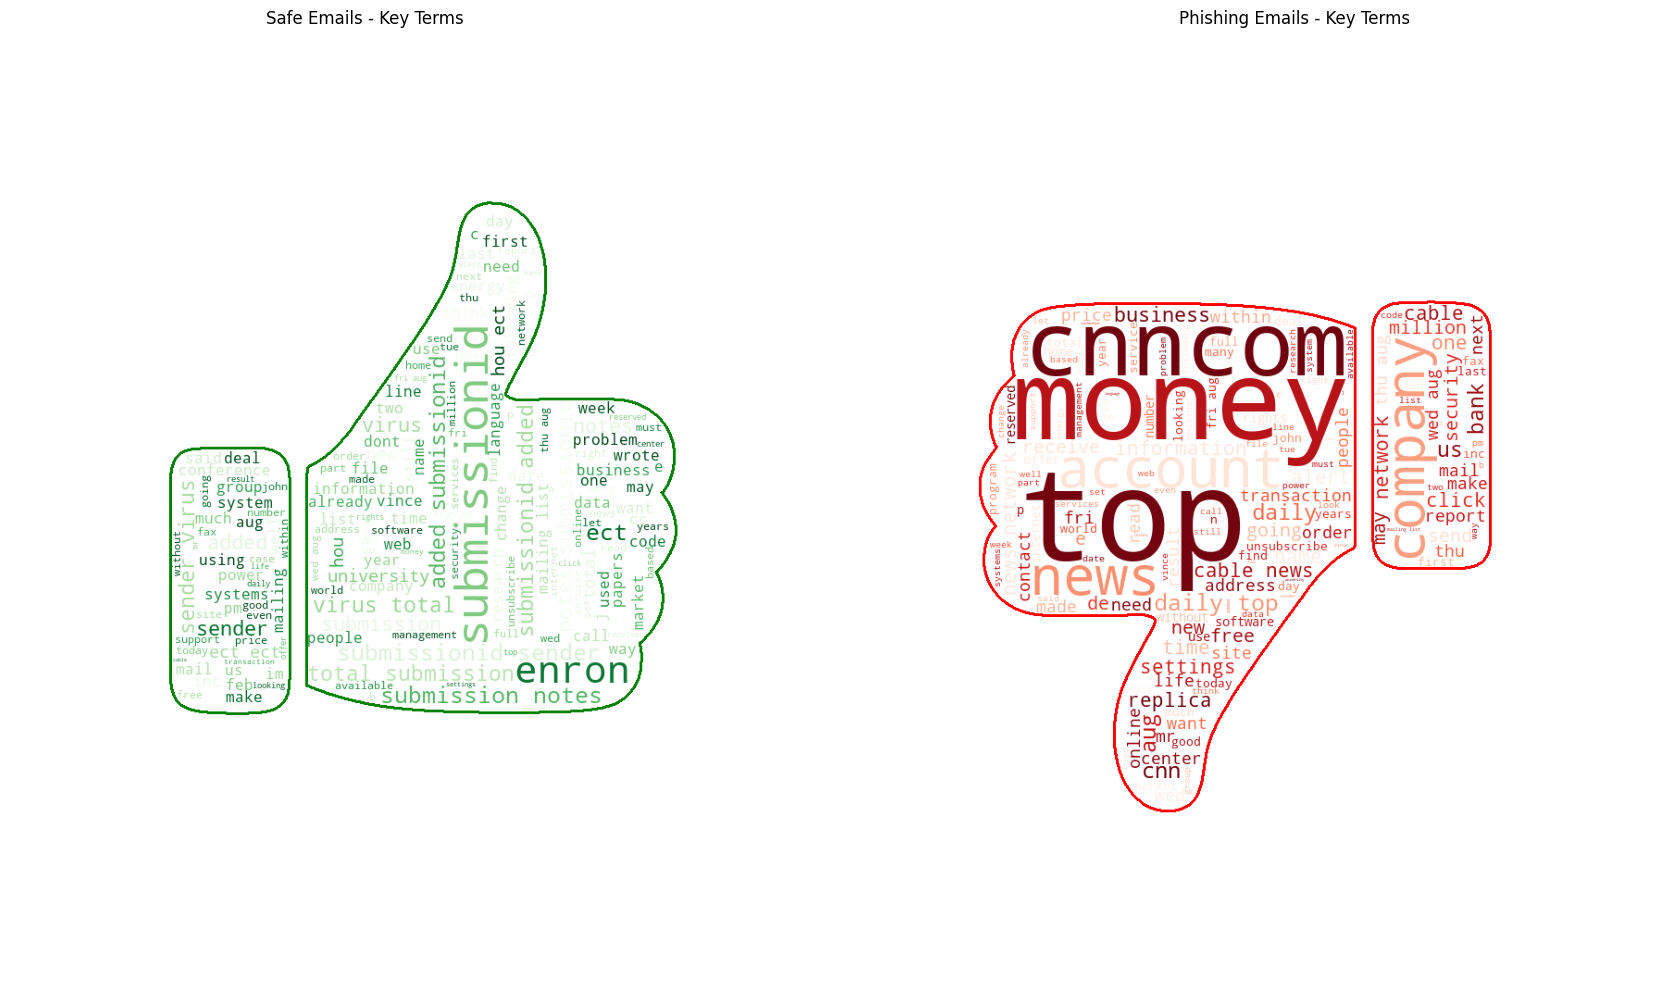

In [4]:
def load_mask(path):
    """Load and convert mask image."""
    mask = Image.open(path).convert("L")
    mask = mask.point(lambda x: 0 if x < 128 else 255, "L")
    return np.array(mask)

safe_text = " ".join(merged_df[merged_df["label"]==0]["email_text"].astype(str).values)
phishing_text = " ".join(merged_df[merged_df["label"]==1]["email_text"].astype(str).values)

try:
    mask_up = load_mask("../pictures/thumbs-up.png")
    mask_down = load_mask("../pictures/thumbs-down.png")
    use_masks = True
    print("✅ Loaded mask images")
except:
    print("⚠️ Mask images missing → generating word clouds without masks")
    use_masks = False
    mask_up = None
    mask_down = None

custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    "subject","re","fw","fwd","please","thanks","dear","hi","hello",
    "original","message","email","sent","from","reply","forward",
    "regards","best","sincerely","get","see","know","go","also",
    "work","help","back","now","take","give","tell"
])

print("🔍 Extracting class-specific terms...\n")

tfidf_analyzer = TfidfVectorizer(
    max_features=200,
    ngram_range=(1, 2),
    min_df=3,
    token_pattern=r'(?u)\b\w+\b|https?://\S+|www\.\S+'
)

tfidf_analyzer.fit(merged_df["email_text"].values)
safe_vec = tfidf_analyzer.transform([safe_text])
ph_vec = tfidf_analyzer.transform([phishing_text])
feature_names = tfidf_analyzer.get_feature_names_out()

safe_scores = safe_vec.toarray()[0]
ph_scores = ph_vec.toarray()[0]

safe_word_freq = {feature_names[i]: safe_scores[i] for i in range(len(feature_names))
                  if safe_scores[i] > 0 and feature_names[i].lower() not in custom_stopwords}

phishing_word_freq = {feature_names[i]: ph_scores[i] for i in range(len(feature_names))
                      if ph_scores[i] > 0 and feature_names[i].lower() not in custom_stopwords}

print("✅ Top Safe Terms:")
for w, s in sorted(safe_word_freq.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"   {w}: {s:.4f}")

print("\n✅ Top Phishing Terms:")
for w, s in sorted(phishing_word_freq.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"   {w}: {s:.4f}")

wc_safe = WordCloud(
    width=800, height=800, background_color="white",
    mask=mask_up if use_masks else None,
    colormap="Greens", contour_color="green",
    contour_width=3, relative_scaling=0.5
).generate_from_frequencies(safe_word_freq)

wc_phishing = WordCloud(
    width=800, height=800, background_color="white",
    mask=mask_down if use_masks else None,
    colormap="Reds", contour_color="red",
    contour_width=3, relative_scaling=0.5
).generate_from_frequencies(phishing_word_freq)

fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(wc_safe); ax[0].axis("off")
ax[0].set_title("Safe Emails - Key Terms")

ax[1].imshow(wc_phishing); ax[1].axis("off")
ax[1].set_title("Phishing Emails - Key Terms")

plt.tight_layout()
plt.show()

In [5]:
X_text = merged_df["email_text"]
y = merged_df["label"].values

print("🔧 Creating TF-IDF vectorizer...")
tfidf = TfidfVectorizer(
    lowercase=True,
    max_features=10000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    token_pattern=r'(?u)\b\w+\b|https?://\S+|www\.\S+|\S+@\S+',
    strip_accents='unicode',
    analyzer='word'
)

print("\n✅ TF-IDF vectorizer created (not fitted yet)")

🔧 Creating TF-IDF vectorizer...

✅ TF-IDF vectorizer created (not fitted yet)


In [6]:
# Split the data
x_train_text, x_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set: {len(x_train_text)} samples")
print(f"Test set: {len(x_test_text)} samples")

# fit TF-IDF on training data only
print("\n🔧 Fitting TF-IDF on training data...")
x_train = tfidf.fit_transform(x_train_text)
x_test = tfidf.transform(x_test_text)  # Only transform test data

print(f"\n✅ TF-IDF Complete:")
print(f"   Features: {x_train.shape[1]:,}")
print(f"   Training samples: {x_train.shape[0]:,}")
print(f"   Test samples: {x_test.shape[0]:,}")
print(f"   Sparsity: {(1 - x_train.nnz / (x_train.shape[0] * x_train.shape[1])) * 100:.2f}%")

# Cross-validation setup
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Models
logreg = LogisticRegression(max_iter=500, random_state=42)
nb = ComplementNB()
base_svm = LinearSVC(random_state=42, max_iter=1000)
svm_sigmoid = CalibratedClassifierCV(base_svm, cv=5, method="sigmoid")
voting = VotingClassifier(
    estimators=[("lr", logreg), ("nb", nb), ("svm", svm_sigmoid)],
    voting="soft"
)

models = {
    "LogisticRegression": logreg,
    "ComplementNB": nb,
    "SVM_Sigmoid": svm_sigmoid,
    "VotingClassifier": voting
}

cv_f1_scores = {}
test_f1_scores = {}
trained_models = {}

print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print(f"{'='*60}")
    
    # Cross-validation on training data
    scores_cv = cross_val_score(model, x_train, y_train, cv=cv, scoring="f1")
    cv_f1_scores[name] = scores_cv.mean()
    
    # Fit on training data
    model.fit(x_train, y_train)
    trained_models[name] = model
    
    # Evaluate on test data
    y_pred = model.predict(x_test)
    test_f1_scores[name] = f1_score(y_test, y_pred)
    
    print(f"\n📊 Cross-Validation F1: {cv_f1_scores[name]:.4f}")
    print(f"   Std Dev: {scores_cv.std():.4f}")
    
    print(f"\n📊 Test Performance:")
    print(f"   F1 Score: {test_f1_scores[name]:.4f}")
    print(f"   Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"   Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"   Recall: {recall_score(y_test, y_pred):.4f}")
    
    print(f"\n📋 Classification Report:")
    print(classification_report(y_test, y_pred, target_names=["Safe", "Phishing"]))

# Save the vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("\n✅ Saved: tfidf_vectorizer.pkl")

Training set: 64634 samples
Test set: 16159 samples

🔧 Fitting TF-IDF on training data...

✅ TF-IDF Complete:
   Features: 10,000
   Training samples: 64,634
   Test samples: 16,159
   Sparsity: 99.04%

MODEL EVALUATION

Training: LogisticRegression

📊 Cross-Validation F1: 0.9852
   Std Dev: 0.0018

📊 Test Performance:
   F1 Score: 0.9858
   Accuracy: 0.9850
   Precision: 0.9830
   Recall: 0.9887

📋 Classification Report:
              precision    recall  f1-score   support

        Safe       0.99      0.98      0.98      7610
    Phishing       0.98      0.99      0.99      8549

    accuracy                           0.98     16159
   macro avg       0.99      0.98      0.98     16159
weighted avg       0.98      0.98      0.98     16159


Training: ComplementNB

📊 Cross-Validation F1: 0.9428
   Std Dev: 0.0023

📊 Test Performance:
   F1 Score: 0.9403
   Accuracy: 0.9400
   Precision: 0.9927
   Recall: 0.8932

📋 Classification Report:
              precision    recall  f1-score   s

In [7]:
print("\n" + "="*60)
print("⏱️ MODEL SPEED BENCHMARKING")
print("="*60)

speed_results = {}

for name, model in models.items():
    print(f"\n{name}")

    # ---- Training time ----
    start_train = time.perf_counter()
    model.fit(x_train, y_train)
    train_time = time.perf_counter() - start_train

    # ---- Prediction time ----
    start_pred = time.perf_counter()
    _ = model.predict(x_test)
    pred_time = time.perf_counter() - start_pred

    speed_results[name] = {
        "train_time_sec": train_time,
        "predict_time_sec": pred_time
    }

    print(f"   Training time:   {train_time:.4f} seconds")
    print(f"   Prediction time: {pred_time:.4f} seconds")


⏱️ MODEL SPEED BENCHMARKING

LogisticRegression
   Training time:   0.6184 seconds
   Prediction time: 0.0053 seconds

ComplementNB
   Training time:   0.0577 seconds
   Prediction time: 0.0130 seconds

SVM_Sigmoid
   Training time:   9.3641 seconds
   Prediction time: 0.0358 seconds

VotingClassifier
   Training time:   9.9550 seconds
   Prediction time: 0.0813 seconds


In [8]:
print("\n" + "="*60)
print("📊 ROC-AUC ANALYSIS")
print("="*60)

roc_auc_scores = {}

for name, model in trained_models.items():
    # Get probability predictions
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(x_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(x_test)
    else:
        print(f"⚠️ {name} doesn't support probability predictions, skipping ROC-AUC")
        continue
    
    # Calculate ROC-AUC
    auc = roc_auc_score(y_test, y_proba)
    roc_auc_scores[name] = auc
    
    print(f"\n{name}:")
    print(f"   ROC-AUC Score: {auc:.4f}")

# Print summary
print("\n" + "="*60)
print("📈 ROC-AUC SUMMARY")
print("="*60)
sorted_models = sorted(roc_auc_scores.items(), key=lambda x: x[1], reverse=True)
for i, (name, auc) in enumerate(sorted_models, 1):
    print(f"{i}. {name:<25} AUC = {auc:.4f}")
print("="*60)


📊 ROC-AUC ANALYSIS

LogisticRegression:
   ROC-AUC Score: 0.9984

ComplementNB:
   ROC-AUC Score: 0.9954

SVM_Sigmoid:
   ROC-AUC Score: 0.9988

VotingClassifier:
   ROC-AUC Score: 0.9987

📈 ROC-AUC SUMMARY
1. SVM_Sigmoid               AUC = 0.9988
2. VotingClassifier          AUC = 0.9987
3. LogisticRegression        AUC = 0.9984
4. ComplementNB              AUC = 0.9954


In [9]:
best_model_name = max(cv_f1_scores, key=cv_f1_scores.get)
best_model = trained_models[best_model_name]

print("\n" + "="*60)
print("🏆 BEST MODEL SELECTION")
print("="*60)
print(f"\nBest Model: {best_model_name}")
print(f"CV F1: {cv_f1_scores[best_model_name]:.4f}")
print(f"Test F1: {test_f1_scores[best_model_name]:.4f}")

print(f"\n🔄 Retraining {best_model_name} on FULL training + test dataset...")

X_full = tfidf.transform(X_text)  # Transform all text with already-fitted vectorizer
best_model.fit(X_full, y)

joblib.dump(best_model, "model.pkl")
print("\n✅ Saved: model.pkl")


🏆 BEST MODEL SELECTION

Best Model: SVM_Sigmoid
CV F1: 0.9884
Test F1: 0.9872

🔄 Retraining SVM_Sigmoid on FULL training + test dataset...

✅ Saved: model.pkl


In [10]:
print("\n" + "="*60)
print("🎲 MODEL STABILITY ANALYSIS")
print("="*60)
print("Evaluating model across 10 different random splits...\n")

seeds = np.arange(10)
accuracies = []
f1_scores_list = []

for seed in tqdm(seeds, desc="Running experiments", ncols=80):
    # Split with different random seed
    x_tr_text, x_te_text, y_tr, y_te = train_test_split(
        X_text, y, test_size=0.2, stratify=y, random_state=seed
    )
    
    # Create vectorizer
    tfidf_temp = TfidfVectorizer(
        lowercase=True,
        max_features=10000,
        ngram_range=(1, 3),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        token_pattern=r'(?u)\b\w+\b|https?://\S+|www\.\S+|\S+@\S+',
        strip_accents='unicode',
        analyzer='word'
    )
    
    x_tr = tfidf_temp.fit_transform(x_tr_text)
    x_te = tfidf_temp.transform(x_te_text)
    
    # Train and evaluate
    model_copy = clone(trained_models[best_model_name])
    model_copy.fit(x_tr, y_tr)
    y_pred = model_copy.predict(x_te)
    
    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    
    accuracies.append(acc)
    f1_scores_list.append(f1)

print("\n✅ Stability Analysis Complete!\n")
print(f"{'Seed':<8} {'Accuracy':<12} {'F1 Score':<12}")
print("-" * 32)
for i, seed in enumerate(seeds):
    print(f"{seed:<8} {accuracies[i]:<12.4f} {f1_scores_list[i]:<12.4f}")

print("\n" + "="*60)
print(f"📈 Average Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"📈 Average F1 Score: {np.mean(f1_scores_list):.4f} ± {np.std(f1_scores_list):.4f}")
print("="*60)


🎲 MODEL STABILITY ANALYSIS
Evaluating model across 10 different random splits...



Running experiments: 100%|█████████████████████| 10/10 [17:01<00:00, 102.14s/it]


✅ Stability Analysis Complete!

Seed     Accuracy     F1 Score    
--------------------------------
0        0.9864       0.9872      
1        0.9865       0.9873      
2        0.9858       0.9866      
3        0.9879       0.9886      
4        0.9877       0.9884      
5        0.9877       0.9884      
6        0.9863       0.9871      
7        0.9874       0.9881      
8        0.9883       0.9890      
9        0.9878       0.9885      

📈 Average Accuracy: 0.9872 ± 0.0008
📈 Average F1 Score: 0.9879 ± 0.0008


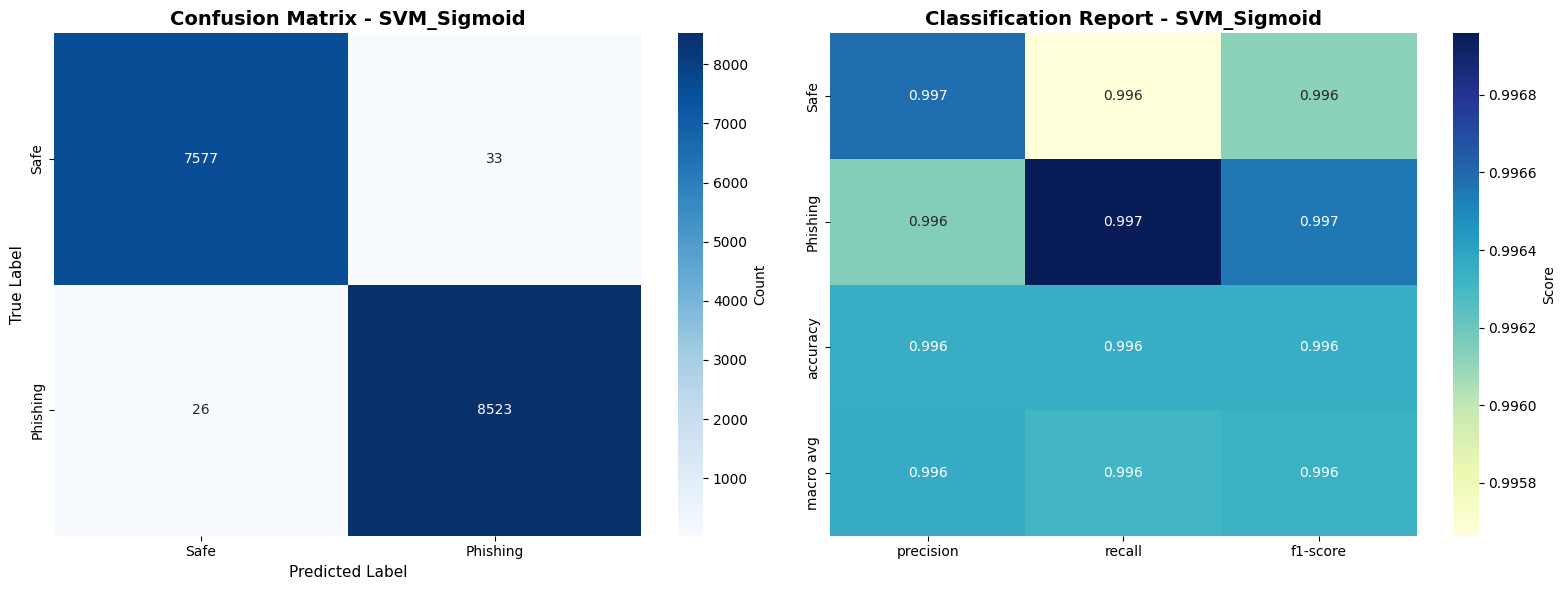


🎯 DETAILED TEST SET METRICS

Model: SVM_Sigmoid

📊 Performance Metrics:
   Accuracy:  0.9963
   Precision: 0.9961
   Recall:    0.9970
   F1 Score:  0.9966
   ROC-AUC:   0.9999
   Avg Precision: 0.9999

📋 Confusion Matrix:
   True Negatives:  7,577
   False Positives: 33
   False Negatives: 26
   True Positives:  8,523

🎯 Additional Metrics:
   Specificity: 0.9957
   False Positive Rate: 0.0043
   False Negative Rate: 0.0030


In [11]:
y_pred = trained_models[best_model_name].predict(x_test)

# Get probabilities for metrics
if hasattr(trained_models[best_model_name], "predict_proba"):
    y_proba = trained_models[best_model_name].predict_proba(x_test)[:, 1]
elif hasattr(trained_models[best_model_name], "decision_function"):
    y_proba = trained_models[best_model_name].decision_function(x_test)
else:
    y_proba = None

# Create a figure with 2 subplots
fig = plt.figure(figsize=(16, 6))

# 1. Confusion Matrix
ax1 = plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Safe", "Phishing"], 
            yticklabels=["Safe", "Phishing"],
            cbar_kws={"label": "Count"}, ax=ax1)
ax1.set_title(f"Confusion Matrix - {best_model_name}", fontsize=14, fontweight="bold")
ax1.set_ylabel("True Label", fontsize=11)
ax1.set_xlabel("Predicted Label", fontsize=11)

# 2. Classification Report Heatmap
ax2 = plt.subplot(1, 2, 2)
report = classification_report(y_test, y_pred, 
                               target_names=["Safe", "Phishing"], 
                               output_dict=True)
report_df = pd.DataFrame(report).iloc[:-1, :-1].T
sns.heatmap(report_df, annot=True, fmt=".3f", cmap="YlGnBu", 
            cbar_kws={"label": "Score"}, ax=ax2)
ax2.set_title(f"Classification Report - {best_model_name}", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

# Print detailed metrics
print("\n" + "="*60)
print("🎯 DETAILED TEST SET METRICS")
print("="*60)
print(f"\nModel: {best_model_name}")
print(f"\n📊 Performance Metrics:")
print(f"   Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"   Precision: {precision_score(y_test, y_pred):.4f}")
print(f"   Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"   F1 Score:  {f1_score(y_test, y_pred):.4f}")

if y_proba is not None:
    print(f"   ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")
    print(f"   Avg Precision: {average_precision_score(y_test, y_proba):.4f}")

print(f"\n📋 Confusion Matrix:")
print(f"   True Negatives:  {cm[0, 0]:,}")
print(f"   False Positives: {cm[0, 1]:,}")
print(f"   False Negatives: {cm[1, 0]:,}")
print(f"   True Positives:  {cm[1, 1]:,}")

# Calculate additional metrics
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
print(f"\n🎯 Additional Metrics:")
print(f"   Specificity: {specificity:.4f}")
print(f"   False Positive Rate: {fp / (fp + tn):.4f}")
print(f"   False Negative Rate: {fn / (fn + tp):.4f}")
print("="*60)